DATA CLEANING

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("zomato.csv")

In [2]:
#here checking column  names
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [3]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [4]:
# df["rest_type"].dtype
# df["rate"].dtype
# df["phone"].dtype
df["cuisines"].dtype

<StringDtype(storage='python', na_value=nan)>

In [5]:
df["rest_type"]=df["rest_type"].fillna(df["rest_type"].mode()[0])

In [6]:
df["rate"]=df["rate"].fillna(df["rate"].mode()[0])

In [7]:
df["phone"]=df["phone"].fillna(df["phone"].mode()[0])

In [8]:
df["location"]=df["location"].fillna(df["location"].mode()[0])

In [9]:
df["dish_liked"]=df["dish_liked"].fillna(df["dish_liked"].mode()[0])

In [10]:
df["approx_cost(for two people)"]=df["approx_cost(for two people)"].fillna(df["approx_cost(for two people)"].mode()[0])

In [11]:
df = df.dropna(subset=["cuisines"])

In [12]:
df.isnull().sum()

url                            0
address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
phone                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [13]:
df['rate'].dtype

<StringDtype(storage='python', na_value=nan)>

In [14]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


DATA ANALYSING

In [15]:
#converting 'rate' into float
df['rate']=df['rate'].str.replace("/5", "")
df['rate']=df['rate'].str.replace("NEW", "")
df['rate']=df['rate'].str.replace("-", "")
df['rate']=df['rate'].str.strip()
df["rate"]=pd.to_numeric(df["rate"],errors='coerce')

In [16]:
#confirming data type 
df['rate'].dtype

dtype('float64')

In [17]:
# average rating of all restaurants
df['rate'].mean()

np.float64(3.7005041532625915)

In [18]:
#Average Rating of all restaurants = 3.70

In [19]:
# top 1 location with highest rating
df.groupby("location")['rate'].mean().idxmax()

'Lavelle Road'

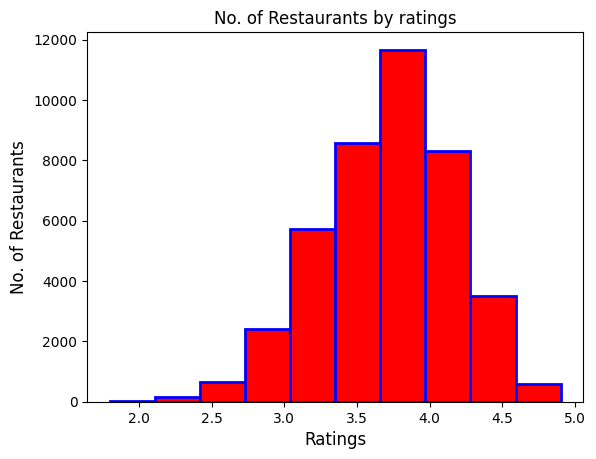

In [20]:
#let's visualize to get some insights
plt.hist(df['rate'],color="r",edgecolor="b",linewidth=2)
plt.xlabel("Ratings",fontsize=12)
plt.ylabel("No. of Restaurants",fontsize=12)
plt.title("No. of Restaurants by ratings")
plt.show()

In [21]:
# top 10 most popular cuisines
x=df['cuisines'].value_counts().head(10)

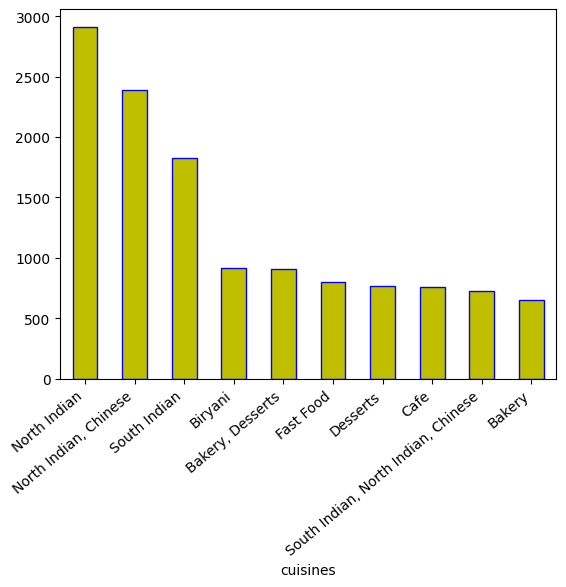

In [22]:
#let's visualize it
x.plot(kind="bar",color="y",edgecolor="b")
plt.xticks(rotation=40, ha='right')
plt.show()

In [23]:
# Average cost for two people
df["approx_cost(for two people)"]=df["approx_cost(for two people)"].str.replace("NEW", "")
df["approx_cost(for two people)"]=df["approx_cost(for two people)"].str.replace("-", "")
df["approx_cost(for two people)"]=df["approx_cost(for two people)"].str.strip()
df["approx_cost(for two people)"]=pd.to_numeric(df["approx_cost(for two people)"],errors='coerce')
df["approx_cost(for two people)"].mean()

np.float64(415.82113730309464)

In [24]:
#Which location is the most expensive
df.groupby("location")['approx_cost(for two people)'].mean().idxmax()

'Rajarajeshwari Nagar'

In [51]:
#Correlation between cost and rating
df["rate"].corr(df["approx_cost(for two people)"])

np.float64(0.19349571249390934)

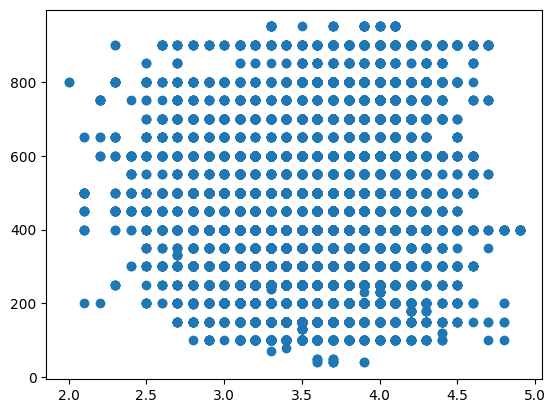

In [52]:
plt.scatter(df["rate"],df['approx_cost(for two people)'])
plt.show()

In [53]:
# What % of restaurants offer online ordering?
y=df['online_order'].value_counts()	

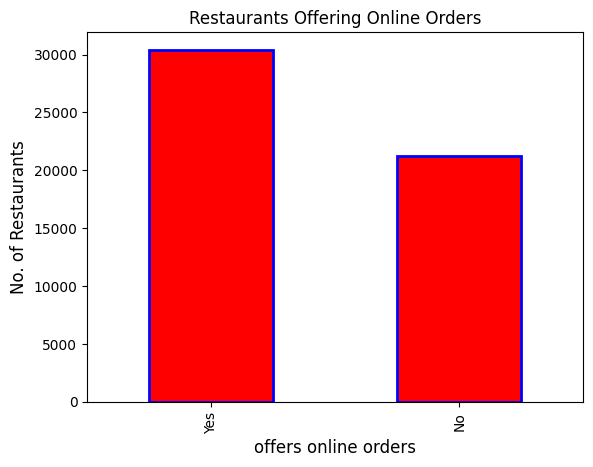

In [54]:
y.plot(kind="bar",color="r",edgecolor="b",linewidth=2)
plt.xlabel("offers online orders",fontsize=12)
plt.ylabel("No. of Restaurants",fontsize=12)
plt.title("Restaurants Offering Online Orders")
plt.show()

In [38]:
# restaurants with table booking have higher or lower ratings
z=df.groupby('book_table')['rate'].mean()

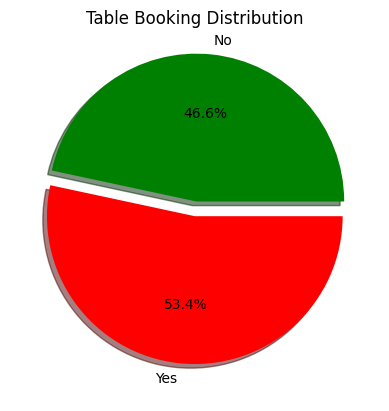

In [47]:
color=['g','r']
ex=[0.1,0.0]
z.plot(kind="pie",explode=ex,colors=color,autopct="%0.1f%%",shadow=True)
plt.title("Table Booking Distribution")
plt.show()

In [29]:
# probability of a restaurant having rating above 4.0
(df['rate']>4.0).sum()/len(df)


np.float64(0.17835578262888993)

#Only 17.8% of restaurants have rating above 4.0

In [55]:
df.to_csv("zomato1.csv")